# 03. Model Training

This notebook trains and compares three classification models 
to predict credit default (`SeriousDlqin2yrs`).

**Models covered:**
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost

Each model is trained on the preprocessed data from 
`02_preprocessing.ipynb`. Results will be compared in 
`04_evaluation.ipynb`.

## 1. Import Libraries & Load Processed Data

In [22]:
%pip install xgboost
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# File and metadata management
from pathlib import Path

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Model persistence
import joblib

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [24]:
# Suppress warnings for cleaner output
import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn
warnings.filterwarnings("ignore")

In [25]:
# Load processed data
data_path = Path("C:/Users/USER/Documents/code_learning/credit-default-prediction/data/processed")

X_train = pd.read_csv(data_path / "X_train.csv")
X_test  = pd.read_csv(data_path / "X_test.csv")
y_train = pd.read_csv(data_path / "y_train.csv").squeeze()
y_test  = pd.read_csv(data_path / "y_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)

X_train shape: (119512, 10)
X_test shape:  (29878, 10)

Class distribution in training set:
SeriousDlqin2yrs
0    93.300254
1     6.699746
Name: proportion, dtype: float64


## 2. Addressing Class Imbalance

The dataset is heavily imbalanced — only 6.7% of borrowers 
defaulted. If left unaddressed, models tend to predict the 
majority class (no default) for almost every case, achieving 
high accuracy but failing to identify actual defaulters.

**Strategy: `class_weight='balanced'`**  
This automatically adjusts the weight of each class inversely 
proportional to its frequency. The minority class (default = 1) 
is given higher weight, penalising the model more for missing 
a defaulter than for a false alarm.

This approach is applied to Logistic Regression and Random Forest. 
XGBoost uses the equivalent `scale_pos_weight` parameter.

In [26]:
# Calculate scale_pos_weight for XGBoost
# = number of negative cases / number of positive cases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative cases (no default): {neg}")
print(f"Positive cases (default):    {pos}")
print(f"scale_pos_weight:            {scale_pos_weight:.2f}")

Negative cases (no default): 111505
Positive cases (default):    8007
scale_pos_weight:            13.93


## 3. Model 1 — Logistic Regression (Baseline)

Logistic Regression is used as a **baseline model**. 

A baseline gives us a reference point — if a more complex model 
(Random Forest, XGBoost) cannot outperform logistic regression, 
it suggests the added complexity is not justified.

Logistic Regression is also highly interpretable — the 
coefficients directly indicate the direction and magnitude 
of each feature's effect on default probability.

In [27]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

# Predictions
lr_pred       = lr.predict(X_test)
lr_pred_proba = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression training complete.")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, lr_pred_proba):.4f}")

Logistic Regression training complete.

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.77      0.86     27876
           1       0.19      0.75      0.30      2002

    accuracy                           0.77     29878
   macro avg       0.58      0.76      0.58     29878
weighted avg       0.92      0.77      0.82     29878

AUC-ROC: 0.8377


## 4. Model 2 — Random Forest

Random Forest is an ensemble of decision trees. Each tree is 
trained on a random subset of the data and features, and the 
final prediction is determined by majority vote.

**Why Random Forest?**
- Handles non-linear relationships well
- Robust to outliers compared to single decision trees
- Provides feature importance scores
- Less prone to overfitting than a single deep decision tree

`n_estimators=100` means 100 trees are built and averaged.
`n_jobs=-1` uses all available CPU cores for faster training.

In [28]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
rf_pred       = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_pred_proba):.4f}")

Random Forest training complete.

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27876
           1       0.55      0.16      0.25      2002

    accuracy                           0.94     29878
   macro avg       0.75      0.58      0.61     29878
weighted avg       0.92      0.94      0.92     29878

AUC-ROC: 0.8379


## 5. Model 3 — XGBoost

XGBoost (Extreme Gradient Boosting) is a boosting algorithm 
that builds trees sequentially — each new tree focuses on 
correcting the errors made by the previous one.

**Why XGBoost?**
- Consistently strong performance on tabular data
- Widely used in industry, especially in Fintech and banking
- Built-in regularisation reduces overfitting
- Handles class imbalance via `scale_pos_weight`

**Key parameters:**
- `n_estimators=200`: Number of boosting rounds
- `max_depth=4`: Limits tree depth to prevent overfitting
- `learning_rate=0.05`: Small steps for more stable learning
- `scale_pos_weight`: Corrects for class imbalance

In [29]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)

# Predictions
xgb_pred       = xgb.predict(X_test)
xgb_pred_proba = xgb.predict_proba(X_test)[:, 1]

print("XGBoost training complete.")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_pred_proba):.4f}")

XGBoost training complete.

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27876
           1       0.22      0.79      0.34      2002

    accuracy                           0.79     29878
   macro avg       0.60      0.79      0.61     29878
weighted avg       0.93      0.79      0.84     29878

AUC-ROC: 0.8664


## XGBoost + SMOTE

SMOTE (Synthetic Minority Oversampling Technique) generates 
synthetic samples of the minority class to balance the 
training set (111,505 vs 111,505).

Compared to the original XGBoost:
- AUC-ROC slightly lower (0.8573 vs 0.8664)
- Precision significantly higher (0.37 vs 0.22)
- Recall lower (0.50 vs 0.79)
- F1-Score higher (0.42 vs 0.34)

**Trade-off interpretation:**  
SMOTE produces a more conservative model — it predicts default 
less aggressively but is more accurate when it does. Whether 
this is preferable depends on the business context:

- If the priority is **catching as many defaulters as possible** 
  (minimise false negatives) → Original XGBoost
- If the priority is **precision in default predictions** 
  (minimise false alarms) → XGBoost + SMOTE

For this project, **original XGBoost is selected as the final model** 
based on higher AUC-ROC and Recall, as missing a defaulter is 
considered more costly than a false alarm in credit risk contexts.

In [30]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())

xgb_sm = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_sm.fit(X_train_sm, y_train_sm)
xgb_sm_proba = xgb_sm.predict_proba(X_test)[:, 1]
xgb_sm_pred  = xgb_sm.predict(X_test)

print(f"\nXGBoost + SMOTE AUC-ROC: {roc_auc_score(y_test, xgb_sm_proba):.4f}")
print(classification_report(y_test, xgb_sm_pred))

Before SMOTE: {0: 111505, 1: 8007}
After SMOTE:  {0: 111505, 1: 111505}

XGBoost + SMOTE AUC-ROC: 0.8573
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27876
           1       0.37      0.50      0.42      2002

    accuracy                           0.91     29878
   macro avg       0.67      0.72      0.69     29878
weighted avg       0.92      0.91      0.92     29878



## 6. Model Comparison

All three models are compared side by side using:

- **AUC-ROC**: Primary metric — measures the model's ability 
  to distinguish between defaulters and non-defaulters across 
  all classification thresholds. Higher is better (max = 1.0).
- **Precision**: Of all predicted defaulters, how many actually 
  defaulted?
- **Recall**: Of all actual defaulters, how many did the model 
  catch? This is critical in credit risk — missing a defaulter 
  is costly.
- **F1-Score**: Harmonic mean of Precision and Recall. Useful 
  when classes are imbalanced.

**Why AUC-ROC and not Accuracy?**  
With 93.3% non-defaulters, a model that always predicts 
"no default" achieves 93.3% accuracy — but catches zero 
actual defaulters. AUC-ROC is immune to this trap.

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Logistic Regression': (lr_pred, lr_pred_proba),
    'Random Forest':       (rf_pred, rf_pred_proba),
    'XGBoost':             (xgb_pred, xgb_pred_proba),
    'XGBoost + SMOTE':     (xgb_sm_pred, xgb_sm_proba)
}

results = []
for name, (pred, proba) in models.items():
    results.append({
        'Model':     name,
        'AUC-ROC':   round(roc_auc_score(y_test, proba), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
        'F1-Score':  round(f1_score(y_test, pred), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

                     AUC-ROC  Precision  Recall  F1-Score
Model                                                    
Logistic Regression   0.8377     0.1898  0.7532    0.3032
Random Forest         0.8379     0.5542  0.1608    0.2493
XGBoost               0.8664     0.2164  0.7897    0.3397
XGBoost + SMOTE       0.8573     0.3681  0.4960    0.4226


### Threshold Analysis

To determine the optimal classification threshold, we evaluated
Precision, Recall, and F1-Score across multiple thresholds
for the XGBoost model.

| Threshold | Precision | Recall | F1 |
|---|---|---|---|
| 0.1 | 0.0825 | 0.9820 | 0.1522 |
| 0.2 | 0.1165 | 0.9356 | 0.2073 |
| 0.3 | 0.1445 | 0.8921 | 0.2487 |
| 0.4 | 0.1758 | 0.8526 | 0.2915 |
| 0.5 | 0.2164 | 0.7897 | 0.3397 |

The default threshold of **0.5 yields the best F1-Score (0.3397)**
and is retained. Lower thresholds increase Recall but significantly
reduce Precision, resulting in too many false alarms to be
practically useful.

In [32]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for thresh in thresholds:
    pred = (xgb_pred_proba >= thresh).astype(int)
    p = precision_score(y_test, pred)
    r = recall_score(y_test, pred)
    f = f1_score(y_test, pred)
    print(f"{thresh:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.1          0.0825       0.9820       0.1522      
0.2          0.1165       0.9356       0.2073      
0.3          0.1445       0.8921       0.2487      
0.4          0.1758       0.8526       0.2915      
0.5          0.2164       0.7897       0.3397      


## 7. ROC Curve Comparison

The ROC curve plots the True Positive Rate (Recall) against
the False Positive Rate at every possible classification threshold.

A model with perfect discrimination hugs the top-left corner.
The diagonal line represents a random classifier (AUC = 0.5).

Note: Given the class imbalance in this dataset (6.7% default),
ROC curves may present an optimistic view of model performance.
A Precision-Recall curve analysis is conducted in
`04_evaluation.ipynb` to provide a more complete picture.

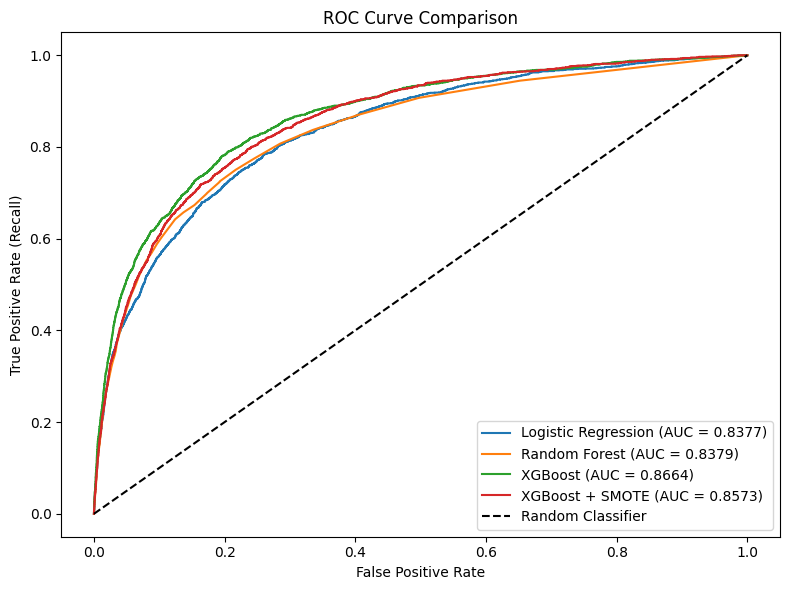

In [33]:
plt.figure(figsize=(8, 6))

for name, (pred, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Feature Importance — Random Forest & XGBoost

Feature importance reveals which variables contribute most 
to each model's predictions. This translates model behaviour 
into actionable business insights:

- High-importance features are the strongest signals of default risk
- Low-importance features may be candidates for removal in 
  future iterations to simplify the model

Both Random Forest and XGBoost provide built-in feature 
importance scores. Comparing both helps confirm which 
features are consistently important across different 
model architectures.

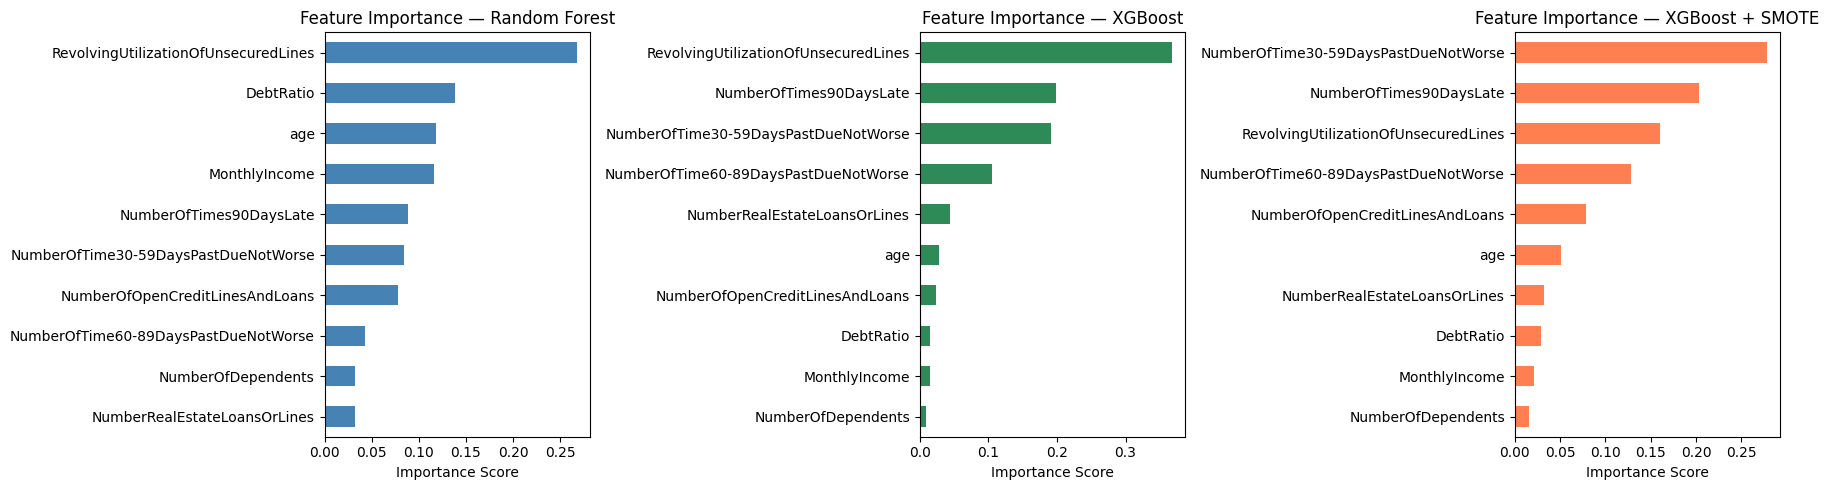

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest feature importance
rf_importance = pd.Series(
    rf.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)

rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Random Forest')
axes[0].set_xlabel('Importance Score')

# XGBoost feature importance
xgb_importance = pd.Series(
    xgb.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)

xgb_importance.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Feature Importance — XGBoost')
axes[1].set_xlabel('Importance Score')

# XGBoost + SMOTE feature importance
xgb_sm_importance = pd.Series(
    xgb_sm.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)

xgb_sm_importance.plot(kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Feature Importance — XGBoost + SMOTE')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 9. Save Models

All three trained models are saved using `joblib` for use 
in the evaluation notebook and potential future deployment.

In [35]:
model_path = Path("../outputs/models")
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(lr,     model_path / "logistic_regression.pkl")
joblib.dump(rf,     model_path / "random_forest.pkl")
joblib.dump(xgb,    model_path / "xgboost.pkl")
joblib.dump(xgb_sm, model_path / "xgboost_smote.pkl")

print("Models saved to ../outputs/models/")
print("  - logistic_regression.pkl")
print("  - random_forest.pkl")
print("  - xgboost.pkl")
print("  - xgboost_smote.pkl")

Models saved to ../outputs/models/
  - logistic_regression.pkl
  - random_forest.pkl
  - xgboost.pkl
  - xgboost_smote.pkl


## 10. Modeling Summary

| Model | AUC-ROC | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Logistic Regression | 0.8377 | 0.1898 | 0.7532 | 0.3032 |
| Random Forest | 0.8379 | 0.5542 | 0.1608 | 0.2493 |
| XGBoost | 0.8664 | 0.2164 | 0.7897 | 0.3397 |
| XGBoost + SMOTE | 0.8573 | 0.3681 | 0.4960 | 0.4226 |

**Final model selected: XGBoost (original)**
Based on highest AUC-ROC (0.8664) and Recall (0.7897).
In credit risk, missing a defaulter (false negative) is more
costly than a false alarm — high Recall is prioritised.

Detailed evaluation and business recommendations are covered
in `04_evaluation.ipynb`.